# Feature Exploration: Extreme Weather Composite (Multi-Route)

This notebook tests the impact of the extreme weather composite feature on the multi-route model.

**Base Model (from 7a with all holidays):**
- Multi-route model with <50 flights/month airline-routes excluded
- Features: lag1, gradient, rainy_days_arr_exp, temp_volatility_total_exp
- Holiday features: aggregate + school holidays

**Extreme Weather Feature:**
- `extreme_weather_days_dep/arr`: Days with temp>35°C OR rain>10mm OR wind>8m/s OR humidity>95%
- Already computed in the data but NEVER tested in ML models

**Variants to Test:**
- `extreme_weather_days_total` = dep + arr
- `extreme_weather_days_total_exp` = exponential transformation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from calendar import monthrange
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

import holidays

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed")

%matplotlib inline

XGBoost available


## 1. Data Preparation

In [2]:
# Load multi-route data
df = pd.read_csv('../data/processed/ml_training_data_multiroute.csv')

df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = df['year_month_dt'].dt.month
df['year'] = df['year'].astype(int)
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']
df['route'] = df['departing_port'] + '_' + df['arriving_port']
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print(f"Original shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")

Original shape: (4140, 60)
Date range: 2010-01 to 2025-11


In [3]:
# Check extreme weather columns
print("Extreme Weather Columns:")
print(f"  extreme_weather_days_dep: {df['extreme_weather_days_dep'].min():.0f} - {df['extreme_weather_days_dep'].max():.0f}")
print(f"  extreme_weather_days_arr: {df['extreme_weather_days_arr'].min():.0f} - {df['extreme_weather_days_arr'].max():.0f}")

# Create combined feature
df['extreme_weather_days_total'] = df['extreme_weather_days_dep'] + df['extreme_weather_days_arr']
print(f"\n  extreme_weather_days_total: {df['extreme_weather_days_total'].min():.0f} - {df['extreme_weather_days_total'].max():.0f}")

# Create exponential transformation
df['extreme_weather_days_total_exp'] = np.exp(df['extreme_weather_days_total'] / df['extreme_weather_days_total'].max())
print(f"  extreme_weather_days_total_exp: {df['extreme_weather_days_total_exp'].min():.2f} - {df['extreme_weather_days_total_exp'].max():.2f}")

Extreme Weather Columns:
  extreme_weather_days_dep: 0 - 21
  extreme_weather_days_arr: 0 - 21

  extreme_weather_days_total: 4 - 35
  extreme_weather_days_total_exp: 1.12 - 2.72


## 2. Generate Holiday Features

In [4]:
years = list(range(2010, 2026))
STATES = ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']

state_holidays = {state: holidays.Australia(years=years, prov=state) for state in STATES}
national_holidays = holidays.Australia(years=years)

def count_holidays_in_month(holiday_dict, year, month):
    count = 0
    _, days_in_month = monthrange(year, month)
    for day in range(1, days_in_month + 1):
        if date(year, month, day) in holiday_dict:
            count += 1
    return count

def has_major_holiday_in_month(holiday_dict, year, month):
    major_keywords = ['christmas', 'easter', 'anzac', 'good friday', 'boxing']
    _, days_in_month = monthrange(year, month)
    for day in range(1, days_in_month + 1):
        d = date(year, month, day)
        if d in holiday_dict:
            name = holiday_dict[d].lower()
            if any(kw in name for kw in major_keywords):
                return 1
    return 0

def get_school_holiday_periods(year):
    return [
        (date(year-1, 12, 18), date(year, 1, 28)),
        (date(year, 4, 8), date(year, 4, 23)),
        (date(year, 6, 27), date(year, 7, 14)),
        (date(year, 9, 23), date(year, 10, 7)),
        (date(year, 12, 18), date(year, 12, 31)),
    ]

def count_school_holiday_days_in_month(year, month):
    periods = get_school_holiday_periods(year)
    if month == 1:
        periods.extend(get_school_holiday_periods(year))
    _, days_in_month = monthrange(year, month)
    holiday_days = 0
    for day in range(1, days_in_month + 1):
        current_date = date(year, month, day)
        for start, end in periods:
            if start <= current_date <= end:
                holiday_days += 1
                break
    return holiday_days

print("Holiday functions defined.")

Holiday functions defined.


In [5]:
year_months = df[['year', 'month_num']].drop_duplicates().sort_values(['year', 'month_num'])
print(f"Generating holiday features for {len(year_months)} unique months...")

holiday_features = []
for _, row in year_months.iterrows():
    year, month = int(row['year']), int(row['month_num'])
    _, days_in_month = monthrange(year, month)
    
    feature_row = {'year': year, 'month_num': month}
    feature_row['n_public_holidays_national'] = count_holidays_in_month(national_holidays, year, month)
    
    all_holiday_dates = set()
    for state in STATES:
        for day in range(1, days_in_month + 1):
            d = date(year, month, day)
            if d in state_holidays[state]:
                all_holiday_dates.add(d)
    feature_row['n_public_holidays_total'] = len(all_holiday_dates)
    
    has_major = 0
    for state in STATES:
        if has_major_holiday_in_month(state_holidays[state], year, month):
            has_major = 1
            break
    feature_row['has_major_holiday'] = has_major
    
    school_days = count_school_holiday_days_in_month(year, month)
    feature_row['school_holiday_days'] = school_days
    feature_row['pct_school_holiday'] = round(school_days / days_in_month, 4)
    
    holiday_features.append(feature_row)

df_holidays = pd.DataFrame(holiday_features)
df = df.merge(df_holidays, on=['year', 'month_num'], how='left')
print(f"Shape after adding holidays: {df.shape}")

Generating holiday features for 182 unique months...
Shape after adding holidays: (4140, 67)


## 3. Filter Low-Volume Airline-Routes

In [6]:
volume_threshold = 50
airline_route_volume = df.groupby('airline_route')['sectors_scheduled'].mean().reset_index()
airline_route_volume.columns = ['airline_route', 'avg_volume']
high_volume_ar = airline_route_volume[airline_route_volume['avg_volume'] >= volume_threshold]['airline_route'].tolist()
df_filtered = df[df['airline_route'].isin(high_volume_ar)].copy()

print(f"Volume threshold: {volume_threshold} flights/month")
print(f"Records before filtering: {len(df)}")
print(f"Records after filtering:  {len(df_filtered)}")

Volume threshold: 50 flights/month
Records before filtering: 4140
Records after filtering:  3614


## 4. Explore Extreme Weather Feature

In [7]:
# Correlations
print("Extreme Weather Feature Correlations with delay_rate:")
print("=" * 60)
print(f"  extreme_weather_days_dep:       {df_filtered['extreme_weather_days_dep'].corr(df_filtered['delay_rate']):.4f}")
print(f"  extreme_weather_days_arr:       {df_filtered['extreme_weather_days_arr'].corr(df_filtered['delay_rate']):.4f}")
print(f"  extreme_weather_days_total:     {df_filtered['extreme_weather_days_total'].corr(df_filtered['delay_rate']):.4f}")
print(f"  extreme_weather_days_total_exp: {df_filtered['extreme_weather_days_total_exp'].corr(df_filtered['delay_rate']):.4f}")

# Compare with other weather features already in use
print("\nComparison with existing weather features:")
print(f"  rainy_days_arr:                 {df_filtered['rainy_days_arr'].corr(df_filtered['delay_rate']):.4f}")
print(f"  temp_volatility_dep:            {df_filtered['temp_volatility_dep'].corr(df_filtered['delay_rate']):.4f}")
print(f"  temp_volatility_arr:            {df_filtered['temp_volatility_arr'].corr(df_filtered['delay_rate']):.4f}")

Extreme Weather Feature Correlations with delay_rate:
  extreme_weather_days_dep:       0.0416
  extreme_weather_days_arr:       0.1472
  extreme_weather_days_total:     0.1430
  extreme_weather_days_total_exp: 0.1362

Comparison with existing weather features:
  rainy_days_arr:                 0.1122
  temp_volatility_dep:            0.0411
  temp_volatility_arr:            0.0464


In [8]:
# By route
print("\nExtreme Weather Correlation by Route:")
print("=" * 70)
print(f"{'Route':<20} {'extreme_total':>15} {'extreme_exp':>15} {'Mean Days':>12}")
print("-" * 70)

for route in sorted(df_filtered['route'].unique()):
    route_data = df_filtered[df_filtered['route'] == route]
    corr_total = route_data['extreme_weather_days_total'].corr(route_data['delay_rate'])
    corr_exp = route_data['extreme_weather_days_total_exp'].corr(route_data['delay_rate'])
    mean_days = route_data['extreme_weather_days_total'].mean()
    print(f"{route:<20} {corr_total:>15.4f} {corr_exp:>15.4f} {mean_days:>12.1f}")


Extreme Weather Correlation by Route:
Route                  extreme_total     extreme_exp    Mean Days
----------------------------------------------------------------------
Hobart_Melbourne              0.1029          0.0981         18.0
Hobart_Sydney                 0.2518          0.2394         14.6
Melbourne_Hobart              0.1613          0.1569         18.0
Melbourne_Sydney              0.0733          0.0754         19.9
Sydney_Hobart                 0.1725          0.1655         14.6
Sydney_Melbourne              0.0382          0.0414         19.9


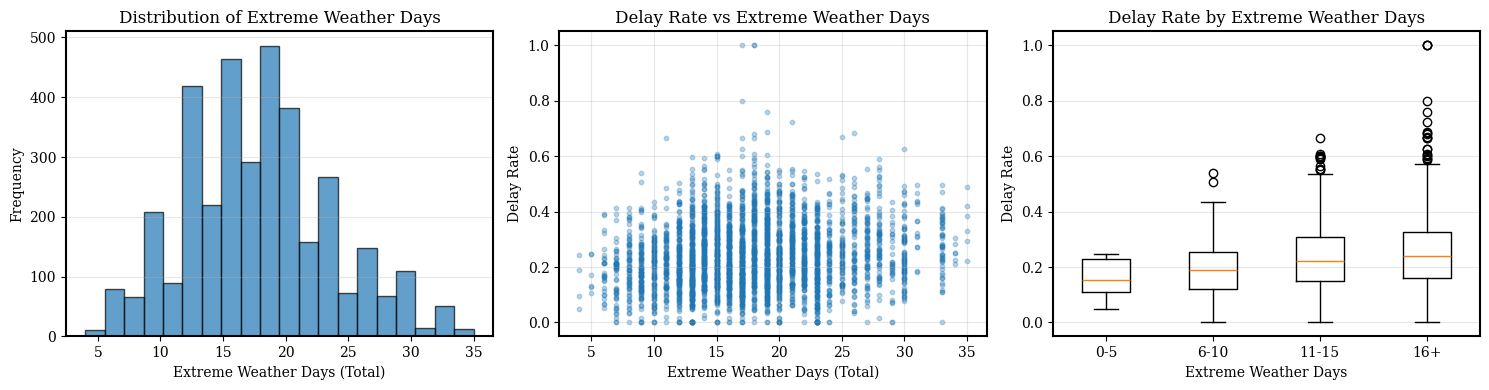

In [9]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Distribution of extreme weather days
ax = axes[0]
ax.hist(df_filtered['extreme_weather_days_total'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Extreme Weather Days (Total)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Extreme Weather Days')
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Scatter of extreme weather vs delay
ax = axes[1]
ax.scatter(df_filtered['extreme_weather_days_total'], df_filtered['delay_rate'], alpha=0.3, s=10)
ax.set_xlabel('Extreme Weather Days (Total)')
ax.set_ylabel('Delay Rate')
ax.set_title('Delay Rate vs Extreme Weather Days')
ax.grid(True, alpha=0.3)

# Plot 3: Boxplot by extreme weather bins
ax = axes[2]
df_filtered['extreme_bin'] = pd.cut(df_filtered['extreme_weather_days_total'], 
                                     bins=[0, 5, 10, 15, 50], 
                                     labels=['0-5', '6-10', '11-15', '16+'])
bins = ['0-5', '6-10', '11-15', '16+']
delay_by_bin = [df_filtered[df_filtered['extreme_bin'] == b]['delay_rate'].values for b in bins]
ax.boxplot(delay_by_bin, labels=bins)
ax.set_xlabel('Extreme Weather Days')
ax.set_ylabel('Delay Rate')
ax.set_title('Delay Rate by Extreme Weather Days')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [10]:
# Lagged features
df_filtered['delay_rate_lag1'] = df_filtered.groupby('airline_route')['delay_rate'].shift(1)
df_filtered['delay_rate_lag2'] = df_filtered.groupby('airline_route')['delay_rate'].shift(2)
df_filtered['delay_rate_gradient'] = df_filtered['delay_rate_lag1'] - df_filtered['delay_rate_lag2']

# Cyclical month
df_filtered['month_sin'] = np.sin(2 * np.pi * df_filtered['month_num'] / 12)
df_filtered['month_cos'] = np.cos(2 * np.pi * df_filtered['month_num'] / 12)

# One-hot encoding
airline_dummies = pd.get_dummies(df_filtered['airline'], prefix='airline')
df_filtered = pd.concat([df_filtered, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

route_dummies = pd.get_dummies(df_filtered['route'], prefix='route')
df_filtered = pd.concat([df_filtered, route_dummies], axis=1)
route_cols = list(route_dummies.columns)

# Weather features
df_filtered['rainy_days_arr_exp'] = np.exp(df_filtered['rainy_days_arr'] / df_filtered['rainy_days_arr'].max())
df_filtered['temp_volatility_total'] = df_filtered['temp_volatility_dep'] + df_filtered['temp_volatility_arr']
df_filtered['temp_volatility_total_exp'] = np.exp(df_filtered['temp_volatility_total'] / df_filtered['temp_volatility_total'].max())

# Drop NaN
df_clean = df_filtered.dropna(subset=['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_gradient']).copy()
print(f"Rows after dropping NaN: {len(df_clean)}")

Rows after dropping NaN: 3562


## 6. Train/Validation/Test Split

In [11]:
train_mask = ((df_clean['year'] <= 2017) | (df_clean['year'] == 2024))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2023))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2024): {train_mask.sum()} samples")
print(f"Validation (2018, 2023): {val_mask.sum()} samples")
print(f"Test (2019, 2025):       {test_mask.sum()} samples")

Train (2010-2017, 2024): 2083 samples
Validation (2018, 2023): 504 samples
Test (2019, 2025):       447 samples


In [12]:
# Feature sets
base_features = airline_cols + route_cols + ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled']
weather_features = ['rainy_days_arr_exp', 'delay_rate_gradient', 'temp_volatility_total_exp']
holiday_features = ['n_public_holidays_national', 'n_public_holidays_total', 'has_major_holiday',
                    'school_holiday_days', 'pct_school_holiday']

# Baseline = 7a with all holidays
baseline_features = base_features + weather_features + holiday_features

# Variants to test
extreme_variants = {
    'baseline (7a)': baseline_features,
    '+extreme_plain': baseline_features + ['extreme_weather_days_total'],
    '+extreme_exp': baseline_features + ['extreme_weather_days_total_exp'],
}

print("Feature variants:")
for name, features in extreme_variants.items():
    print(f"  {name}: {len(features)} features")

Feature variants:
  baseline (7a): 25 features
  +extreme_plain: 26 features
  +extreme_exp: 26 features


In [13]:
# Target variables
y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
y_val_reg = df_clean.loc[val_mask, 'delay_rate'].values
y_test_reg = df_clean.loc[test_mask, 'delay_rate'].values

y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
y_val_clf = df_clean.loc[val_mask, 'is_high_delay'].values
y_test_clf = df_clean.loc[test_mask, 'is_high_delay'].values

print("Target variables prepared.")

Target variables prepared.


## 7. Regression Models

In [14]:
reg_results = []

for variant_name, features in extreme_variants.items():
    print(f"\n{'='*60}")
    print(f"Regression with: {variant_name}")
    print(f"{'='*60}")
    
    X_train = df_clean.loc[train_mask, features].values
    X_val = df_clean.loc[val_mask, features].values
    X_test = df_clean.loc[test_mask, features].values
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train_reg)
    ridge_test_pred = ridge.predict(X_test_scaled)
    ridge_r2 = r2_score(y_test_reg, ridge_test_pred)
    ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred))
    print(f"  Ridge:    R²={ridge_r2:.4f}, RMSE={ridge_rmse:.4f}")
    reg_results.append({'Variant': variant_name, 'Model': 'Ridge', 'Test_R2': ridge_r2, 'Test_RMSE': ridge_rmse})
    
    # Random Forest
    rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf_reg.fit(X_train, y_train_reg)
    rf_test_pred = rf_reg.predict(X_test)
    rf_r2 = r2_score(y_test_reg, rf_test_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_test_pred))
    print(f"  RF:       R²={rf_r2:.4f}, RMSE={rf_rmse:.4f}")
    reg_results.append({'Variant': variant_name, 'Model': 'Random Forest', 'Test_R2': rf_r2, 'Test_RMSE': rf_rmse})

reg_df = pd.DataFrame(reg_results)


Regression with: baseline (7a)
  Ridge:    R²=0.4523, RMSE=0.0806
  RF:       R²=0.4727, RMSE=0.0791

Regression with: +extreme_plain
  Ridge:    R²=0.4522, RMSE=0.0806
  RF:       R²=0.4844, RMSE=0.0782

Regression with: +extreme_exp
  Ridge:    R²=0.4531, RMSE=0.0805
  RF:       R²=0.4844, RMSE=0.0782


## 8. Classification Models

In [15]:
clf_results = []

for variant_name, features in extreme_variants.items():
    print(f"\n{'='*60}")
    print(f"Classification with: {variant_name}")
    print(f"{'='*60}")
    
    X_train = df_clean.loc[train_mask, features].values
    X_val = df_clean.loc[val_mask, features].values
    X_test = df_clean.loc[test_mask, features].values
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Logistic
    logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    logreg.fit(X_train_scaled, y_train_clf)
    logreg_test_pred = logreg.predict(X_test_scaled)
    logreg_test_proba = logreg.predict_proba(X_test_scaled)[:, 1]
    logreg_f1 = f1_score(y_test_clf, logreg_test_pred)
    logreg_auc = roc_auc_score(y_test_clf, logreg_test_proba)
    print(f"  Logistic: F1={logreg_f1:.4f}, AUC={logreg_auc:.4f}")
    clf_results.append({'Variant': variant_name, 'Model': 'Logistic', 'Test_F1': logreg_f1, 'Test_AUC': logreg_auc})
    
    # Random Forest
    rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf_clf.fit(X_train, y_train_clf)
    rf_clf_test_pred = rf_clf.predict(X_test)
    rf_clf_test_proba = rf_clf.predict_proba(X_test)[:, 1]
    rf_clf_f1 = f1_score(y_test_clf, rf_clf_test_pred)
    rf_clf_auc = roc_auc_score(y_test_clf, rf_clf_test_proba)
    print(f"  RF Clf:   F1={rf_clf_f1:.4f}, AUC={rf_clf_auc:.4f}")
    clf_results.append({'Variant': variant_name, 'Model': 'Random Forest', 'Test_F1': rf_clf_f1, 'Test_AUC': rf_clf_auc})
    
    # XGBoost
    if HAS_XGB:
        xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, min_child_weight=5, random_state=42, n_jobs=-1)
        xgb_clf.fit(X_train, y_train_clf, eval_set=[(X_val, y_val_clf)], verbose=False)
        xgb_test_pred = xgb_clf.predict(X_test)
        xgb_test_proba = xgb_clf.predict_proba(X_test)[:, 1]
        xgb_f1 = f1_score(y_test_clf, xgb_test_pred)
        xgb_auc = roc_auc_score(y_test_clf, xgb_test_proba)
        print(f"  XGBoost:  F1={xgb_f1:.4f}, AUC={xgb_auc:.4f}")
        clf_results.append({'Variant': variant_name, 'Model': 'XGBoost', 'Test_F1': xgb_f1, 'Test_AUC': xgb_auc})

clf_df = pd.DataFrame(clf_results)


Classification with: baseline (7a)
  Logistic: F1=0.7657, AUC=0.8781
  RF Clf:   F1=0.7604, AUC=0.8641
  XGBoost:  F1=0.7489, AUC=0.8548

Classification with: +extreme_plain
  Logistic: F1=0.7710, AUC=0.8829
  RF Clf:   F1=0.7565, AUC=0.8725
  XGBoost:  F1=0.7805, AUC=0.8696

Classification with: +extreme_exp
  Logistic: F1=0.7681, AUC=0.8826
  RF Clf:   F1=0.7565, AUC=0.8725
  XGBoost:  F1=0.7805, AUC=0.8696


## 9. Results Comparison

In [16]:
# Regression comparison
print("=" * 80)
print("REGRESSION: Baseline (7a) vs +Extreme Weather")
print("=" * 80)

reg_pivot = reg_df.pivot(index='Model', columns='Variant', values='Test_R2')
reg_pivot = reg_pivot[['baseline (7a)', '+extreme_plain', '+extreme_exp']]

print(f"\n{'Model':<15} {'baseline':>12} {'+plain':>12} {'+exp':>12}")
print("-" * 55)
for model in reg_pivot.index:
    row = reg_pivot.loc[model]
    print(f"{model:<15} {row['baseline (7a)']:>12.4f} {row['+extreme_plain']:>12.4f} {row['+extreme_exp']:>12.4f}")

REGRESSION: Baseline (7a) vs +Extreme Weather

Model               baseline       +plain         +exp
-------------------------------------------------------
Random Forest         0.4727       0.4844       0.4844
Ridge                 0.4523       0.4522       0.4531


In [17]:
# Classification comparison
print("=" * 80)
print("CLASSIFICATION: Baseline (7a) vs +Extreme Weather")
print("=" * 80)

clf_pivot = clf_df.pivot(index='Model', columns='Variant', values='Test_F1')
clf_pivot = clf_pivot[['baseline (7a)', '+extreme_plain', '+extreme_exp']]

print(f"\n{'Model':<15} {'baseline':>12} {'+plain':>12} {'+exp':>12}")
print("-" * 55)
for model in clf_pivot.index:
    row = clf_pivot.loc[model]
    print(f"{model:<15} {row['baseline (7a)']:>12.4f} {row['+extreme_plain']:>12.4f} {row['+extreme_exp']:>12.4f}")

CLASSIFICATION: Baseline (7a) vs +Extreme Weather

Model               baseline       +plain         +exp
-------------------------------------------------------
Logistic              0.7657       0.7710       0.7681
Random Forest         0.7604       0.7565       0.7565
XGBoost               0.7489       0.7805       0.7805


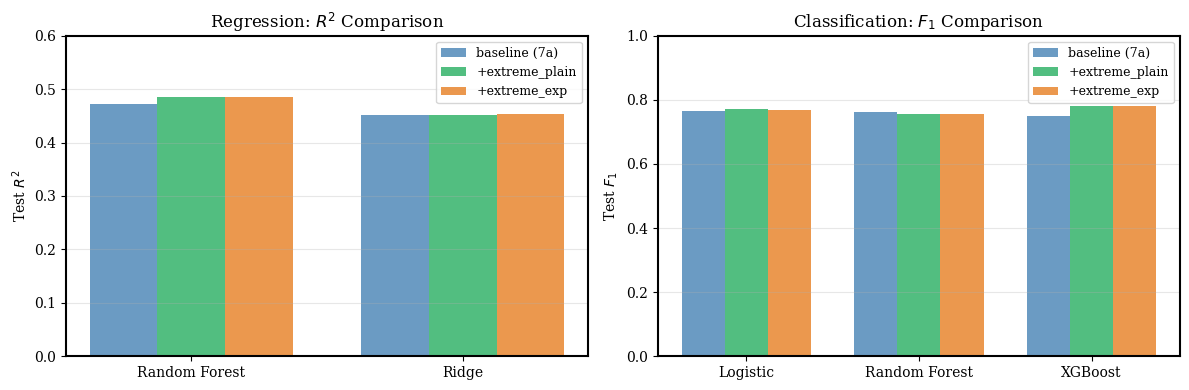

In [18]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regression
ax = axes[0]
x_reg = np.arange(len(reg_pivot.index))
width = 0.25
colors = ['steelblue', '#27ae60', '#e67e22']

for i, variant in enumerate(['baseline (7a)', '+extreme_plain', '+extreme_exp']):
    ax.bar(x_reg + i*width, reg_pivot[variant], width, label=variant, color=colors[i], alpha=0.8)

ax.set_ylabel(r'Test $R^2$')
ax.set_title(r'Regression: $R^2$ Comparison')
ax.set_xticks(x_reg + width)
ax.set_xticklabels(reg_pivot.index)
ax.legend(fontsize=9)
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3, axis='y')

# Classification
ax = axes[1]
x_clf = np.arange(len(clf_pivot.index))

for i, variant in enumerate(['baseline (7a)', '+extreme_plain', '+extreme_exp']):
    ax.bar(x_clf + i*width, clf_pivot[variant], width, label=variant, color=colors[i], alpha=0.8)

ax.set_ylabel(r'Test $F_1$')
ax.set_title(r'Classification: $F_1$ Comparison')
ax.set_xticks(x_clf + width)
ax.set_xticklabels(clf_pivot.index)
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Feature Importance

In [19]:
# Train RF with extreme_plain to check feature importance
features_with_extreme = baseline_features + ['extreme_weather_days_total']
X_train_reg = df_clean.loc[train_mask, features_with_extreme].values

rf_final = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_final.fit(X_train_reg, y_train_reg)

importance_df = pd.DataFrame({
    'Feature': features_with_extreme,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (RF Regression with extreme weather):")
print("-" * 60)
for _, row in importance_df.head(15).iterrows():
    marker = " <- EXTREME" if 'extreme' in row['Feature'] else ""
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}{marker}")

# Find extreme rank
extreme_rank = list(importance_df['Feature']).index('extreme_weather_days_total') + 1
extreme_importance = importance_df[importance_df['Feature'] == 'extreme_weather_days_total']['Importance'].values[0]
print(f"\nextreme_weather_days_total: rank {extreme_rank}, importance {extreme_importance:.4f}")

Feature Importance (RF Regression with extreme weather):
------------------------------------------------------------
  delay_rate_lag1                     0.5579
  sectors_scheduled                   0.0695
  temp_volatility_total_exp           0.0685
  delay_rate_gradient                 0.0660
  extreme_weather_days_total          0.0458 <- EXTREME
  rainy_days_arr_exp                  0.0415
  month_sin                           0.0257
  n_public_holidays_total             0.0241
  pct_school_holiday                  0.0148
  month_cos                           0.0137
  school_holiday_days                 0.0127
  airline_Jetstar                     0.0116
  airline_QantasLink                  0.0088
  n_public_holidays_national          0.0081
  route_Hobart_Melbourne              0.0056

extreme_weather_days_total: rank 5, importance 0.0458


## 11. Summary and Recommendations

In [20]:
print("="*80)
print("SUMMARY: Impact of Extreme Weather Composite on Multi-Route Model")
print("="*80)

# Summary metrics table - Regression
print("\nREGRESSION PERFORMANCE:")
print("-" * 70)
print(f"{'Model':<15} {'7a Baseline':>12} {'7c +Extreme':>12} {'Δ R²':>10} {'Status':>12}")
print("-" * 70)

for model in reg_pivot.index:
    baseline = reg_pivot.loc[model, 'baseline (7a)']
    best = max(reg_pivot.loc[model, '+extreme_plain'], reg_pivot.loc[model, '+extreme_exp'])
    diff = best - baseline
    sign = '+' if diff > 0 else ''
    status = 'IMPROVED' if diff > 0.005 else ('WORSE' if diff < -0.005 else '~same')
    print(f"{model:<15} {baseline:>12.4f} {best:>12.4f} {sign}{diff:>9.4f} {status:>12}")

# Summary metrics table - Classification
print("\nCLASSIFICATION PERFORMANCE:")
print("-" * 70)
print(f"{'Model':<15} {'7a Baseline':>12} {'7c +Extreme':>12} {'Δ F1':>10} {'Status':>12}")
print("-" * 70)

for model in clf_pivot.index:
    baseline = clf_pivot.loc[model, 'baseline (7a)']
    best = max(clf_pivot.loc[model, '+extreme_plain'], clf_pivot.loc[model, '+extreme_exp'])
    diff = best - baseline
    sign = '+' if diff > 0 else ''
    status = 'IMPROVED' if diff > 0.005 else ('WORSE' if diff < -0.005 else '~same')
    print(f"{model:<15} {baseline:>12.4f} {best:>12.4f} {sign}{diff:>9.4f} {status:>12}")

# Count improvements
reg_improvements = sum(1 for m in reg_pivot.index 
    if max(reg_pivot.loc[m, '+extreme_plain'], reg_pivot.loc[m, '+extreme_exp']) - reg_pivot.loc[m, 'baseline (7a)'] > 0.005)
clf_improvements = sum(1 for m in clf_pivot.index 
    if max(clf_pivot.loc[m, '+extreme_plain'], clf_pivot.loc[m, '+extreme_exp']) - clf_pivot.loc[m, 'baseline (7a)'] > 0.005)

total_models = len(reg_pivot.index) + len(clf_pivot.index)
total_improvements = reg_improvements + clf_improvements

print(f"""
ADDITIONAL FINDINGS:

1. EXTREME WEATHER CORRELATION:
   - Correlation with delay_rate: {df_filtered['extreme_weather_days_total'].corr(df_filtered['delay_rate']):.4f}
   - Combines: temp>35°C OR rain>10mm OR wind>8m/s OR humidity>95%

2. REGRESSION IMPACT:
   - Models improved: {reg_improvements}/{len(reg_pivot.index)}

3. CLASSIFICATION IMPACT:
   - Models improved: {clf_improvements}/{len(clf_pivot.index)}

4. FEATURE IMPORTANCE:
   - Extreme weather rank: {extreme_rank} out of {len(features_with_extreme)}
   - Importance: {extreme_importance:.4f}

5. TOTAL MODELS IMPROVED: {total_improvements}/{total_models}
""")

# Recommendation
print("="*80)
print("RECOMMENDATION")
print("="*80)

if total_improvements >= 3:
    best_variant = 'exp' if sum(reg_pivot['+extreme_exp']) + sum(clf_pivot['+extreme_exp']) > \
                            sum(reg_pivot['+extreme_plain']) + sum(clf_pivot['+extreme_plain']) else 'plain'
    print(f"\nRECOMMEND: Include extreme weather feature ({best_variant} transformation)")
    print(f"  - Improves {total_improvements}/{total_models} models")
else:
    print(f"\nRECOMMEND: Do NOT include extreme weather feature")
    print(f"  - Only improves {total_improvements}/{total_models} models")
    print("  - Composite feature may overlap with existing weather features")
    print("  - (rainy_days, temp_volatility already capture similar information)")

SUMMARY: Impact of Extreme Weather Composite on Multi-Route Model

REGRESSION PERFORMANCE:
----------------------------------------------------------------------
Model            7a Baseline  7c +Extreme       Δ R²       Status
----------------------------------------------------------------------
Random Forest         0.4727       0.4844 +   0.0117     IMPROVED
Ridge                 0.4523       0.4531 +   0.0007        ~same

CLASSIFICATION PERFORMANCE:
----------------------------------------------------------------------
Model            7a Baseline  7c +Extreme       Δ F1       Status
----------------------------------------------------------------------
Logistic              0.7657       0.7710 +   0.0054     IMPROVED
Random Forest         0.7604       0.7565   -0.0039        ~same
XGBoost               0.7489       0.7805 +   0.0316     IMPROVED

ADDITIONAL FINDINGS:

1. EXTREME WEATHER CORRELATION:
   - Correlation with delay_rate: 0.1430
   - Combines: temp>35°C OR rain>10mm O